# Fintech alert triage — escalation prediction (team 365B6DEC)

End-to-end, top-to-bottom reproducible solution: **EDA → feature engineering → modeling → validation → submission**.

* Task: predict `eskalatsiya` (1 = alert escalated) for each `signal_id` from its many-to-one transaction history. Metric: **ROC-AUC**.
* Reusable code lives in `../src/` (`data.py`, `features.py`, `model.py`, `pipeline.py`, `tune.py`); this notebook calls it.
* **Random seeds**: `SEED = 42` for the evaluation folds, model seeds `42, 43, 44` for LightGBM bagging; `TUNE_SEED = 7` is a *separate* fold split used only for hyper-parameter / blend-weight selection, so the reported OOF AUC is never tuned on its own folds.
* Charts are displayed inline **and** saved to `../eda_site/assets/` for the static EDA website.

In [1]:
import os, sys, json, time, warnings, pickle
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")
warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

from src import data as D
from src.features import build_features, fit_type_stats, feature_columns
from src.pipeline import build_feature_tables
from src import model as M

SEED, TUNE_SEED, LGB_SEEDS = 42, 7, (42, 43, 44)
np.random.seed(SEED)

ASSETS = ROOT / "eda_site" / "assets"; ASSETS.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)
OUTPUT = ROOT / "output"; OUTPUT.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C_NEG, C_POS, C_ACC = "#5b7aa5", "#d1495b", "#2a9d8f"
PAL = {0: C_NEG, 1: C_POS}

def save(fig, name):
    fig.tight_layout()
    fig.savefig(ASSETS / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()

pd.set_option("display.width", 160, "display.max_columns", 40)
print("root:", ROOT)

root: /Users/khojee/projects/wiut_hackathon


## 1. Data loading and schema
The data folder on disk is `fintech_data/` (the brief said `fintech data/`). The sample submission file is named `sample_submission (3).csv`.

In [2]:
print(sorted(p.name for p in D.DATA_DIR.iterdir()))
train_sig = D.load_signals("train"); test_sig = D.load_signals("test")
train_tx_raw = D.load_transactions("train"); test_tx_raw = D.load_transactions("test")
sample_sub = D.load_sample_submission()

for name, df in [("train_signals", train_sig), ("test_signals", test_sig),
                 ("train_transactions", train_tx_raw), ("test_transactions", test_tx_raw),
                 ("sample_submission", sample_sub)]:
    print(f"\n=== {name}: shape={df.shape}")
    print(df.dtypes.to_string())
    print("missing values:", df.isna().sum().to_dict())

['sample_submission (3).csv', 'test_signals.csv', 'test_transactions.parquet', 'train_signals.csv', 'train_transactions.parquet']



=== train_signals: shape=(14000, 3)
signal_id                   str
signal_sanasi    datetime64[us]
eskalatsiya               int64
missing values: {'signal_id': 0, 'signal_sanasi': 0, 'eskalatsiya': 0}

=== test_signals: shape=(6000, 2)
signal_id                   str
signal_sanasi    datetime64[us]
missing values: {'signal_id': 0, 'signal_sanasi': 0}

=== train_transactions: shape=(6987663, 5)
signal_id                       str
tranzaksiya_vaqti    datetime64[us]
kirim_chiqim                    str
tranzaksiya_turi                str
miqdor_indeksi              float64
missing values: {'signal_id': 0, 'tranzaksiya_vaqti': 0, 'kirim_chiqim': 0, 'tranzaksiya_turi': 0, 'miqdor_indeksi': 0}

=== test_transactions: shape=(3027575, 5)
signal_id                       str
tranzaksiya_vaqti    datetime64[us]
kirim_chiqim                    str
tranzaksiya_turi                str
miqdor_indeksi              float64
missing values: {'signal_id': 0, 'tranzaksiya_vaqti': 0, 'kirim_chiqim': 0, '

In [3]:
print("signal date range  train:", train_sig.signal_sanasi.min().date(), "->", train_sig.signal_sanasi.max().date(),
      "| test:", test_sig.signal_sanasi.min().date(), "->", test_sig.signal_sanasi.max().date())
print("tx time range      train:", train_tx_raw.tranzaksiya_vaqti.min(), "->", train_tx_raw.tranzaksiya_vaqti.max())
print("                   test: ", test_tx_raw.tranzaksiya_vaqti.min(), "->", test_tx_raw.tranzaksiya_vaqti.max())
for c in ["kirim_chiqim", "tranzaksiya_turi"]:
    print(f"\n{c} value counts (train):"); print(train_tx_raw[c].value_counts().to_string())
print("\nunique signal_ids in tx  train:", train_tx_raw.signal_id.nunique(), " test:", test_tx_raw.signal_id.nunique())
print("duplicate signal_ids in signals  train:", train_sig.signal_id.duplicated().sum(), " test:", test_sig.signal_id.duplicated().sum())
print("train/test signal_id overlap:", len(set(train_sig.signal_id) & set(test_sig.signal_id)))
print("signals without any transaction  train:", len(set(train_sig.signal_id) - set(train_tx_raw.signal_id)),
      " test:", len(set(test_sig.signal_id) - set(test_tx_raw.signal_id)))
print("tx rows whose signal_id is unknown  train:", (~train_tx_raw.signal_id.isin(train_sig.signal_id)).sum(),
      " test:", (~test_tx_raw.signal_id.isin(test_sig.signal_id)).sum())
print("fully duplicated tx rows  train:", train_tx_raw.duplicated().sum())
print("sample_submission ids == test ids (same order):", (sample_sub.signal_id.values == test_sig.signal_id.values).all(),
      "| placeholder values:", sample_sub.ehtimollik.unique())

signal date range  train: 2025-01-01 -> 2026-12-31 | test: 2025-01-01 -> 2026-12-31
tx time range      train: 2024-07-05 00:31:36 -> 2026-12-31 00:00:00
                   test:  2024-07-05 00:42:26 -> 2026-12-31 00:00:00

kirim_chiqim value counts (train):
kirim_chiqim
kirim     5286880
chiqim    1700783

tranzaksiya_turi value counts (train):
tranzaksiya_turi
karta             3758797
bank_otkazmasi    2754687
naqd               442346
xalqaro             31833



unique signal_ids in tx  train: 14000  test: 6000
duplicate signal_ids in signals  train: 0  test: 0


train/test signal_id overlap: 0


signals without any transaction  train: 0  test: 0
tx rows whose signal_id is unknown  train: 0  test: 0


fully duplicated tx rows  train: 0
sample_submission ids == test ids (same order): True | placeholder values: [0.5]


### 1.1 Temporal leakage check
We join the alert date onto each transaction (validated many-to-one, so no row duplication) and measure where transactions sit relative to `signal_sanasi`.

In [4]:
train_tx = D.attach_signal_date(train_tx_raw, train_sig)
test_tx = D.attach_signal_date(test_tx_raw, test_sig)
assert len(train_tx) == len(train_tx_raw) and len(test_tx) == len(test_tx_raw), "join duplicated or dropped rows"
rep_tr, rep_te = D.temporal_report(train_tx), D.temporal_report(test_tx)
print("train:", rep_tr); print("test: ", rep_te)
unsorted = train_tx_raw.groupby("signal_id", sort=False).tranzaksiya_vaqti.apply(lambda s: not s.is_monotonic_increasing).mean()
print(f"share of signals whose raw transactions are NOT time-sorted: {unsorted:.1%} -> we always sort before sequence features")
train_tx = D.filter_pre_signal(train_tx); test_tx = D.filter_pre_signal(test_tx)
print("rows kept after pre-signal filter  train:", len(train_tx), " test:", len(test_tx))

train: {'rows': 6987663, 'after_signal_day': 0, 'on_signal_day': 3934, 'on_signal_day_exact_midnight': 3094, 'max_days_before_signal': 180}
test:  {'rows': 3027575, 'after_signal_day': 0, 'on_signal_day': 1456, 'on_signal_day_exact_midnight': 1405, 'max_days_before_signal': 180}


share of signals whose raw transactions are NOT time-sorted: 15.3% -> we always sort before sequence features
rows kept after pre-signal filter  train: 6987663  test: 3027575


history length (days from first tx to alert):
count    14000.0
mean       175.8
std         21.1
min          1.0
25%        179.0
50%        180.0
75%        180.0
max        180.0
days from last tx to alert:
last
0     2620
1    11277
2       14
3       23
4       22
5       17
6       16
7       11


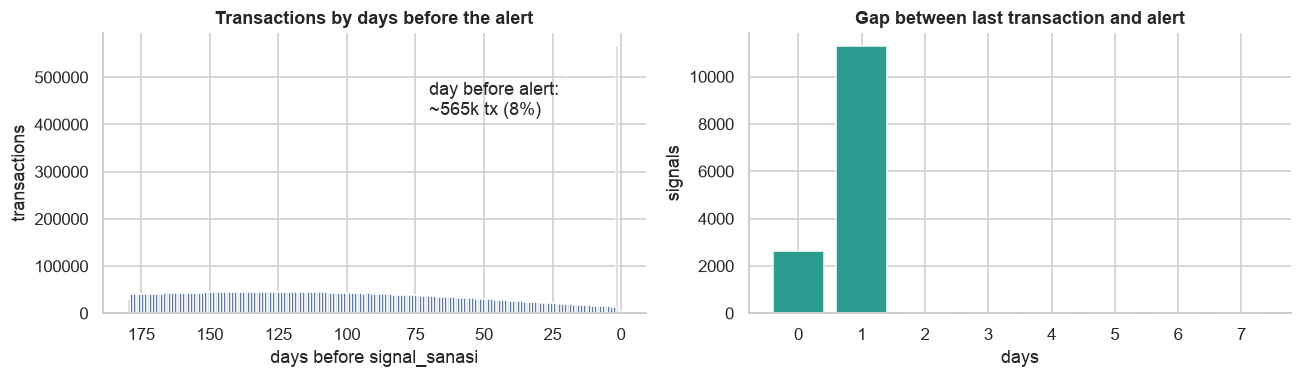

In [5]:
train_tx["days_before"] = (train_tx.signal_sanasi - train_tx.tranzaksiya_vaqti.dt.floor("D")).dt.days
g = train_tx.groupby("signal_id")
win = pd.DataFrame({"first": g.days_before.max(), "last": g.days_before.min()})
print("history length (days from first tx to alert):"); print(win["first"].describe().round(1).to_string())
print("days from last tx to alert:"); print(win["last"].value_counts().sort_index().to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(train_tx.days_before, bins=181, color=C_NEG)
ax[0].set(title="Transactions by days before the alert", xlabel="days before signal_sanasi", ylabel="transactions")
ax[0].invert_xaxis()
ax[0].annotate("day before alert:\n~565k tx (8%)", xy=(1, 5.4e5), xytext=(70, 4.2e5), arrowprops=dict(arrowstyle="->"))
ax[1].bar(win["last"].value_counts().sort_index().index, win["last"].value_counts().sort_index().values, color=C_ACC)
ax[1].set(title="Gap between last transaction and alert", xlabel="days", ylabel="signals")
save(fig, "01_history_window")

**Finding (contradicts the brief's worry):** there are **zero** transactions after the signal date in either split. Every alert comes with a look-back window of at most 180 days that ends on the signal day (usually the last transaction is the day before). About 0.06% of rows fall *on* the signal day (mostly stamped exactly 00:00:00); because `signal_sanasi` has day granularity we treat them as pre-alert history. The filter `tx_time < signal_date + 1 day` is still applied in `src/data.py` so the pipeline stays safe if future data is ever appended.

**But the timestamps are not "clean":** the day before the alert holds ~8% of all transactions — see §2.6, where this turns out to be a burst packed into the final 3 minutes before the alert.

## 2. Exploratory data analysis
### 2.1 Target distribution and time trend

eskalatsiya
0    11595
1     2405
base rate of escalation: 0.1718
signal_sanasi  2025-01  2025-02  2025-03  2025-04  2025-05  2025-06  2025-07  2025-08  2025-09  2025-10  2025-11  2025-12  2026-01  2026-02  2026-03  2026-04  2026-05  2026-06  2026-07  2026-08  2026-09  2026-10  2026-11  2026-12
mean              0.17    0.186    0.176      0.2    0.165    0.143    0.164     0.17    0.139    0.172    0.154    0.175    0.164    0.161    0.199    0.212     0.17    0.144    0.176    0.179    0.175    0.175    0.199    0.191
size            505.00  517.000  505.000    470.0  466.000  497.000  746.000   735.00  696.000  856.000  790.000  805.000  767.000  704.000  778.000  608.000   635.00  634.000  427.000  419.000  395.000  337.000  331.000  377.000


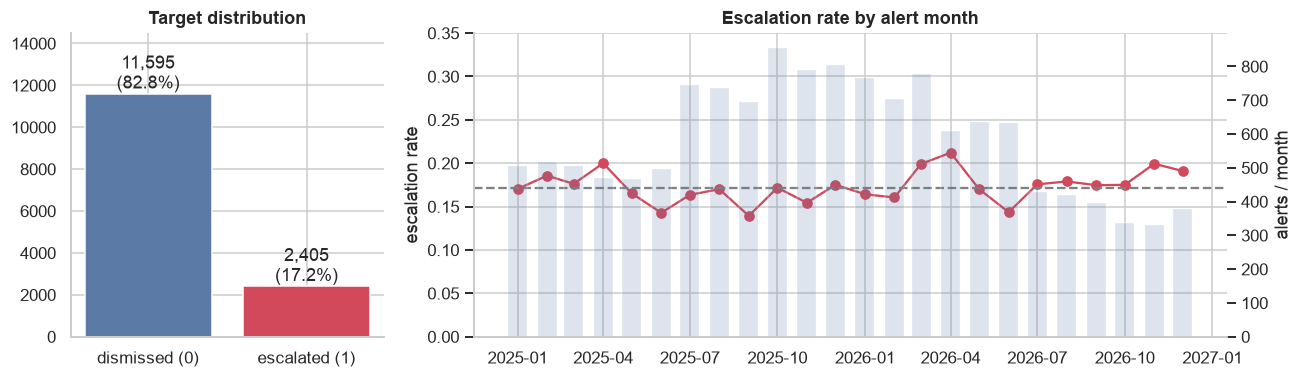

In [6]:
y_all = train_sig.eskalatsiya
print(y_all.value_counts().to_string()); print(f"base rate of escalation: {y_all.mean():.4f}")
by_m = train_sig.groupby(train_sig.signal_sanasi.dt.to_period("M")).eskalatsiya.agg(["mean", "size"])
print(by_m.T.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1, 2.4]})
vc = y_all.value_counts().sort_index()
ax[0].bar(["dismissed (0)", "escalated (1)"], vc.values, color=[C_NEG, C_POS])
for i, v in enumerate(vc.values): ax[0].text(i, v, f"{v:,}\n({v/vc.sum():.1%})", ha="center", va="bottom")
ax[0].set(title="Target distribution", ylim=(0, vc.max() * 1.25))
x = by_m.index.to_timestamp()
ax[1].plot(x, by_m["mean"], marker="o", color=C_POS); ax[1].axhline(y_all.mean(), ls="--", color="grey")
ax2 = ax[1].twinx(); ax2.bar(x, by_m["size"], width=20, alpha=0.2, color=C_NEG); ax2.set_ylabel("alerts / month"); ax2.grid(False)
ax[1].set(title="Escalation rate by alert month", ylabel="escalation rate", ylim=(0, 0.35))
save(fig, "02_target_distribution")

Base rate is **17.2%** — a moderate 1:4.8 imbalance, stable over time (monthly rate stays within noise of the mean). We keep ROC-AUC as the selection metric, use `class_weight='balanced'` in the linear model, and leave boosting unweighted (AUC is rank-based; weighting only changed calibration in trials).

### 2.2 Transaction volume per alert

count    14000.0
mean       499.1
std        299.5
min          1.0
25%        277.0
50%        461.0
75%        678.2
max       2279.0
     count   mean    std  min    25%    50%    75%     max
y                                                         
0  11595.0  494.0  298.5  1.0  272.0  455.0  672.0  2279.0
1   2405.0  523.8  303.0  1.0  299.0  493.0  704.0  2039.0
univariate AUC of n_tx: 0.5306;  signals with <10 tx: 166


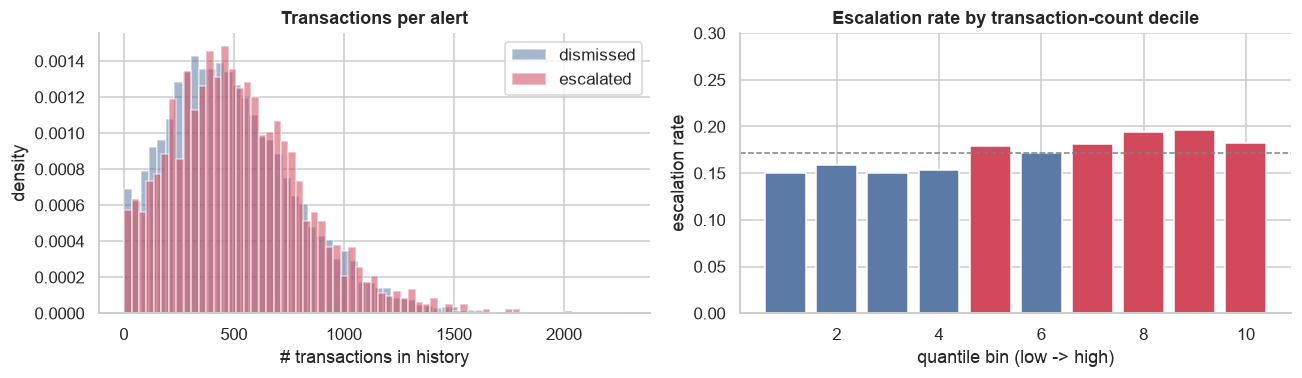

In [7]:
tx = train_tx.merge(train_sig[["signal_id", "eskalatsiya"]], on="signal_id")
sig = tx.groupby("signal_id").agg(y=("eskalatsiya", "first"), n_tx=("miqdor_indeksi", "size"))
print(sig.n_tx.describe().round(1).to_string())
print(sig.groupby("y").n_tx.describe().round(1).to_string())
print(f"univariate AUC of n_tx: {roc_auc_score(sig.y, sig.n_tx):.4f};  signals with <10 tx: {(sig.n_tx < 10).sum()}")

def rate_by_quantile(ax, values, y, title, q=10, xlabel="quantile bin (low -> high)"):
    b = pd.qcut(values.rank(method="first"), q, labels=False)
    r = pd.Series(y.values, index=values.index).groupby(b).mean()
    ax.bar(r.index + 1, r.values, color=[C_POS if v > y.mean() else C_NEG for v in r.values])
    ax.axhline(y.mean(), ls="--", color="grey", lw=1)
    ax.set(title=title, xlabel=xlabel, ylabel="escalation rate", ylim=(0, max(0.3, r.max() * 1.15)))
    return r

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for k in (0, 1):
    ax[0].hist(sig.n_tx[sig.y == k], bins=60, density=True, alpha=0.55, color=PAL[k], label=["dismissed", "escalated"][k])
ax[0].set(title="Transactions per alert", xlabel="# transactions in history", ylabel="density"); ax[0].legend()
rate_by_quantile(ax[1], sig.n_tx, sig.y, "Escalation rate by transaction-count decile")
save(fig, "03_tx_per_signal")

### 2.3 Inflow (kirim) vs outflow (chiqim)

   share_in  in_out_vol_logratio
y                               
0    0.7503               0.8460
1    0.7441               0.8246


eskalatsiya       0      1
kirim_chiqim              
chiqim        0.165  0.100
kirim        -0.215 -0.275
share_in AUC 0.4841
in_out_vol_logratio AUC 0.4892


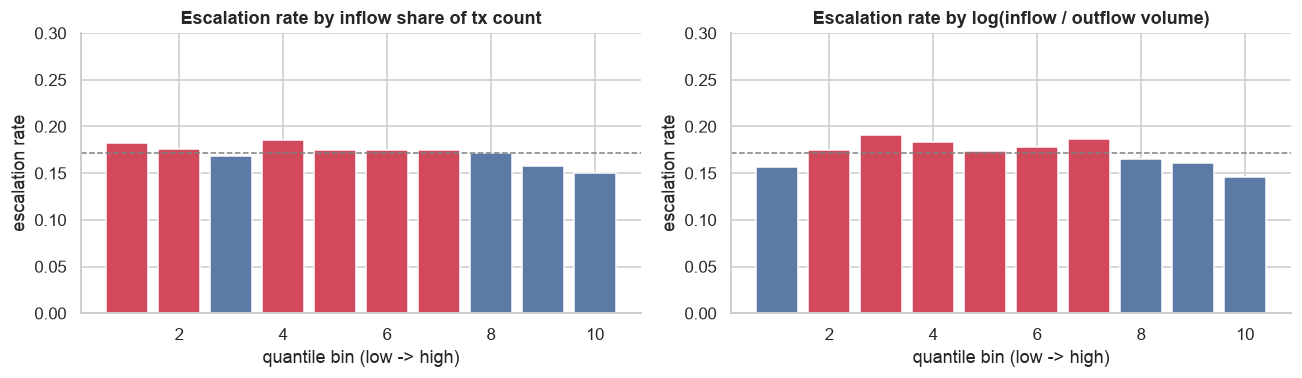

In [8]:
tx["is_in"] = (tx.kirim_chiqim == "kirim").astype(int)
tx["amt_exp"] = np.exp(tx.miqdor_indeksi)
g = tx.groupby("signal_id")
sig["share_in"] = g.is_in.mean()
vol_in = tx[tx.is_in == 1].groupby("signal_id").amt_exp.sum(); vol_out = tx[tx.is_in == 0].groupby("signal_id").amt_exp.sum()
sig["in_out_vol_logratio"] = np.log((vol_in.reindex(sig.index).fillna(0) + 1) / (vol_out.reindex(sig.index).fillna(0) + 1))
print(sig.groupby("y")[["share_in", "in_out_vol_logratio"]].mean().round(4).to_string())
print(tx.groupby(["kirim_chiqim", "eskalatsiya"]).miqdor_indeksi.mean().unstack().round(3).to_string())
for c in ["share_in", "in_out_vol_logratio"]: print(c, "AUC", round(roc_auc_score(sig.y, sig[c]), 4))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
rate_by_quantile(ax[0], sig.share_in, sig.y, "Escalation rate by inflow share of tx count")
rate_by_quantile(ax[1], sig.in_out_vol_logratio, sig.y, "Escalation rate by log(inflow / outflow volume)")
save(fig, "04_direction")

### 2.4 Transaction-type mix — cash (naqd) and international (xalqaro)

   share_karta  share_bank_otkazmasi  share_naqd  share_xalqaro  cash_share_of_volume
y                                                                                    
0       0.5211                0.4123      0.0621         0.0044                0.0962
1       0.5215                0.4092      0.0648         0.0045                0.1093
share_karta              AUC 0.4984
share_bank_otkazmasi     AUC 0.4947
share_naqd               AUC 0.5239
share_xalqaro            AUC 0.5223
cash_share_of_volume     AUC 0.5711
escalation rate | has any international tx: {'mean': {0: 0.154, 1: 0.179}, 'size': {0: 3900, 1: 10100}}


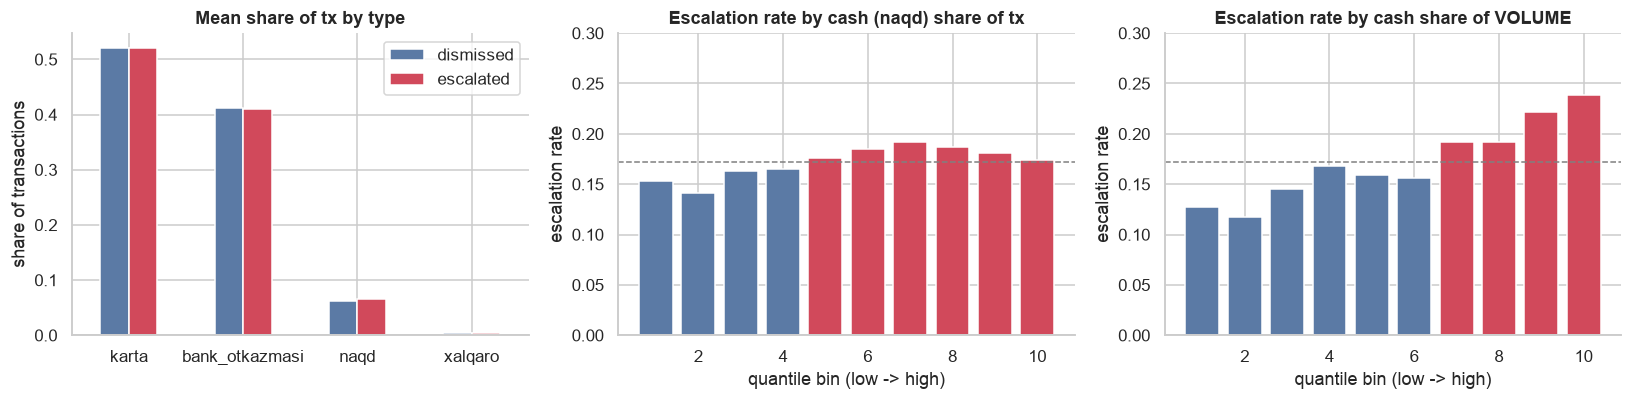

In [9]:
for t in D.TX_TYPES:
    tx[f"is_{t}"] = (tx.tranzaksiya_turi == t).astype(int)
    sig[f"share_{t}"] = tx.groupby("signal_id")[f"is_{t}"].mean()
vol = tx.groupby(["signal_id", "tranzaksiya_turi"]).amt_exp.sum().unstack(fill_value=0)
sig["cash_share_of_volume"] = (vol["naqd"] / vol.sum(axis=1)).reindex(sig.index)
sig["has_intl"] = (sig.share_xalqaro > 0).astype(int)
mix = sig.groupby("y")[[f"share_{t}" for t in D.TX_TYPES] + ["cash_share_of_volume"]].mean()
print(mix.round(4).to_string())
for c in [f"share_{t}" for t in D.TX_TYPES] + ["cash_share_of_volume"]:
    print(f"{c:24s} AUC {roc_auc_score(sig.y, sig[c]):.4f}")
print("escalation rate | has any international tx:", sig.groupby("has_intl").y.agg(["mean", "size"]).round(3).to_dict())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
m = mix[[f"share_{t}" for t in D.TX_TYPES]].T; m.index = D.TX_TYPES
m.plot.bar(ax=ax[0], color=[C_NEG, C_POS], rot=0); ax[0].legend(["dismissed", "escalated"]); ax[0].set(title="Mean share of tx by type", ylabel="share of transactions")
rate_by_quantile(ax[1], sig.share_naqd, sig.y, "Escalation rate by cash (naqd) share of tx")
rate_by_quantile(ax[2], sig.cash_share_of_volume, sig.y, "Escalation rate by cash share of VOLUME")
save(fig, "05_type_mix")

### 2.5 Amount indicator (miqdor_indeksi): distribution, types, tails, clipping

count    6.987663e+06
mean    -1.334000e-01
std      9.811000e-01
min     -2.912300e+00
0.1%    -2.883600e+00
1%      -2.117700e+00
50%     -2.442000e-01
99%      2.639000e+00
99.9%    3.947000e+00
max      6.691700e+00
skew=0.633  kurtosis=0.981


                   mean    std    min    max
tranzaksiya_turi                            
bank_otkazmasi    0.139  1.131 -2.912  6.692
karta            -0.430  0.731 -2.269  4.183
naqd              0.533  0.798 -1.321  4.863
xalqaro           1.989  1.074 -0.578  6.430
hard floor -2.9123: rows below -2.9 = 4,287; their types: {('kirim', 'bank_otkazmasi'): 4287}


per-type caps and number of rows sitting exactly at the cap: {'bank_otkazmasi': (6.692, 11), 'karta': (4.183, 115), 'naqd': (4.863, 6), 'xalqaro': (6.43, 13)}


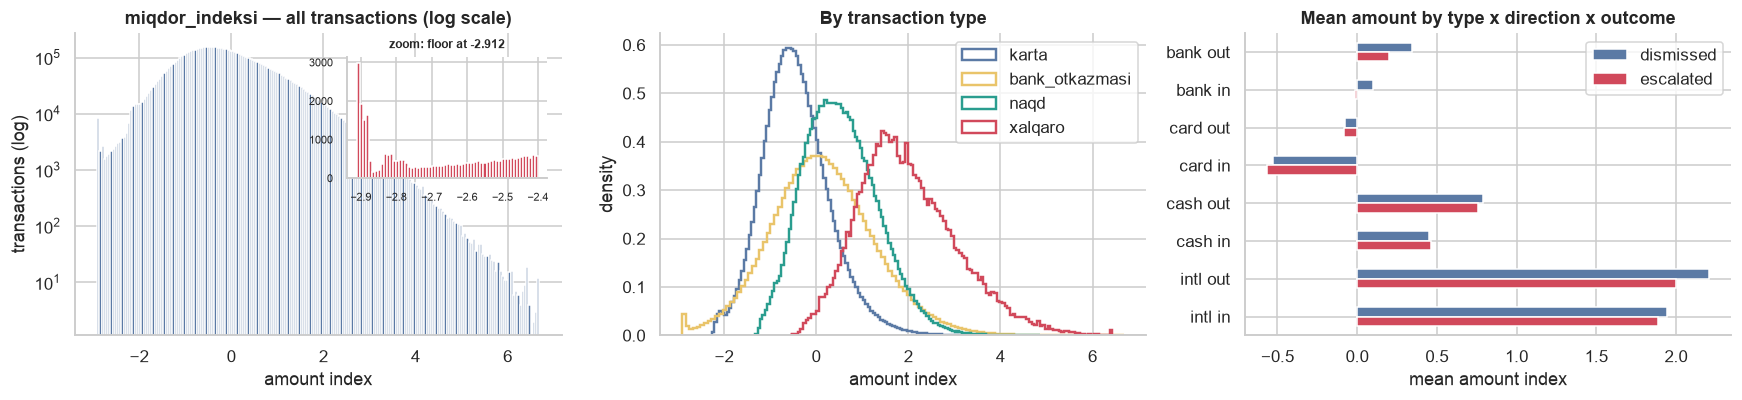

In [10]:
a = tx.miqdor_indeksi
print(a.describe(percentiles=[.001, .01, .5, .99, .999]).round(4).to_string())
print(f"skew={a.skew():.3f}  kurtosis={a.kurt():.3f}")
print(tx.groupby("tranzaksiya_turi").miqdor_indeksi.agg(["mean", "std", "min", "max"]).round(3).to_string())
floor = a.min()
print(f"hard floor {floor:.4f}: rows below -2.9 = {(a < -2.9).sum():,}; their types:", tx[a < -2.9].groupby(["kirim_chiqim", "tranzaksiya_turi"]).size().to_dict())
caps = tx.groupby("tranzaksiya_turi").miqdor_indeksi.max()
print("per-type caps and number of rows sitting exactly at the cap:",
      {t: (round(c, 3), int((tx.miqdor_indeksi[tx.tranzaksiya_turi == t] >= c - 1e-9).sum())) for t, c in caps.items()})

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].hist(a, bins=200, color=C_NEG, log=True); ax[0].set(title="miqdor_indeksi — all transactions (log scale)", xlabel="amount index", ylabel="transactions (log)")
ins = ax[0].inset_axes([0.56, 0.52, 0.41, 0.4])
ins.hist(a[a < -2.4], bins=60, color=C_POS); ins.set_title("zoom: floor at -2.912", fontsize=8); ins.tick_params(labelsize=7)
for t, c in zip(D.TX_TYPES, ["#5b7aa5", "#e9c46a", "#2a9d8f", "#d1495b"]):
    ax[1].hist(tx.miqdor_indeksi[tx.tranzaksiya_turi == t], bins=120, density=True, histtype="step", lw=1.6, color=c, label=t)
ax[1].set(title="By transaction type", xlabel="amount index", ylabel="density"); ax[1].legend()
cell = tx.groupby(["tranzaksiya_turi", "kirim_chiqim", "eskalatsiya"]).miqdor_indeksi.mean().unstack()
short = {"bank_otkazmasi": "bank", "karta": "card", "naqd": "cash", "xalqaro": "intl", "kirim": "in", "chiqim": "out"}
cell.index = [f"{short[t]} {short[d]}" for t, d in cell.index]
cell.plot.barh(ax=ax[2], color=[C_NEG, C_POS]); ax[2].legend(["dismissed", "escalated"], loc="upper right")
ax[2].set(title="Mean amount by type x direction x outcome", xlabel="mean amount index"); ax[2].invert_yaxis()
save(fig, "06_amount_distribution")

amt_mean        AUC 0.4607
z_mean          AUC 0.4571
bank_out_mean   AUC 0.4277
          mean   size
n_floor              
0        0.184  12021
1        0.097   1137
2        0.091    385
3        0.105    457


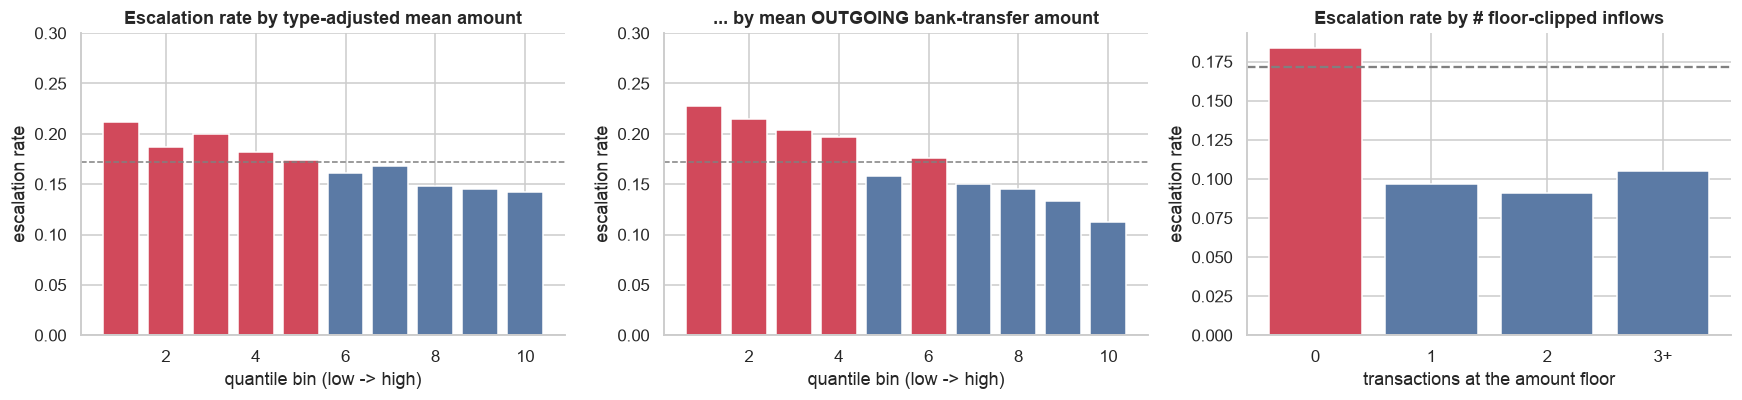

In [11]:
st = tx.groupby(["tranzaksiya_turi", "kirim_chiqim"]).miqdor_indeksi.agg(["mean", "std"])
tx = tx.join(st, on=["tranzaksiya_turi", "kirim_chiqim"]); tx["amt_z"] = (tx.miqdor_indeksi - tx["mean"]) / tx["std"]
sig["amt_mean"] = tx.groupby("signal_id").miqdor_indeksi.mean()
sig["z_mean"] = tx.groupby("signal_id").amt_z.mean()
sig["bank_out_mean"] = tx[(tx.tranzaksiya_turi == "bank_otkazmasi") & (tx.is_in == 0)].groupby("signal_id").miqdor_indeksi.mean()
sig["n_floor"] = tx.assign(f=tx.miqdor_indeksi < -2.9).groupby("signal_id").f.sum()
for c in ["amt_mean", "z_mean", "bank_out_mean"]:
    print(f"{c:15s} AUC {roc_auc_score(sig.y, sig[c].fillna(sig[c].median())):.4f}")
print(sig.groupby(sig.n_floor.clip(0, 3)).y.agg(["mean", "size"]).round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
rate_by_quantile(ax[0], sig.z_mean, sig.y, "Escalation rate by type-adjusted mean amount")
rate_by_quantile(ax[1], sig.bank_out_mean.fillna(sig.bank_out_mean.median()), sig.y, "... by mean OUTGOING bank-transfer amount")
fl = sig.groupby(sig.n_floor.clip(0, 3)).y.mean()
ax[2].bar(["0", "1", "2", "3+"], fl.values, color=[C_POS if v > sig.y.mean() else C_NEG for v in fl.values]); ax[2].axhline(sig.y.mean(), ls="--", color="grey")
ax[2].set(title="Escalation rate by # floor-clipped inflows", xlabel="transactions at the amount floor", ylabel="escalation rate")
save(fig, "07_amount_vs_outcome")

**Amount findings.** `miqdor_indeksi` is a standardised, right-skewed amount index (mean ≈ −0.13, skew ≈ 0.5, long right tail up to 6.7). Each type has its own level (international ≫ cash > bank transfer > card) and its own hard cap (e.g. card capped at 4.18), and there is a **hard floor at −2.912** reached only by *incoming bank transfers* (clipped values). Escalated accounts move **smaller** amounts once type is controlled for — most clearly in outgoing bank transfers — and accounts that have floor-clipped inflows escalate at roughly half the base rate. Raw means are confounded by type mix, so we add **type-adjusted z-scores** (standardised per type × direction using train-only statistics).

### 2.6 Recency / velocity before the alert — the trigger burst

tx on the day before the alert: 565178 | of which in 23:57-23:59: 548696
burst rows: 552,615 (7.9% of all); alerts with a burst: 13,868 / 14,000


     count  mean   std  min   25%   50%   75%    max
y                                                   
0  11595.0  39.2  35.4  0.0  15.0  31.0  54.0  683.0
1   2405.0  40.7  37.8  0.0  15.0  32.0  56.0  785.0
burst size AUC=0.5137 | corr(burst size, account's last-30-day daily rate)=0.699


                  burst  rest of history  burst mean amt  history mean amt
tranzaksiya_turi                                                          
karta             0.604            0.532          -0.683            -0.405
bank_otkazmasi    0.322            0.400          -0.330             0.171
naqd              0.068            0.063           0.066             0.576
xalqaro           0.006            0.004           1.406             2.053


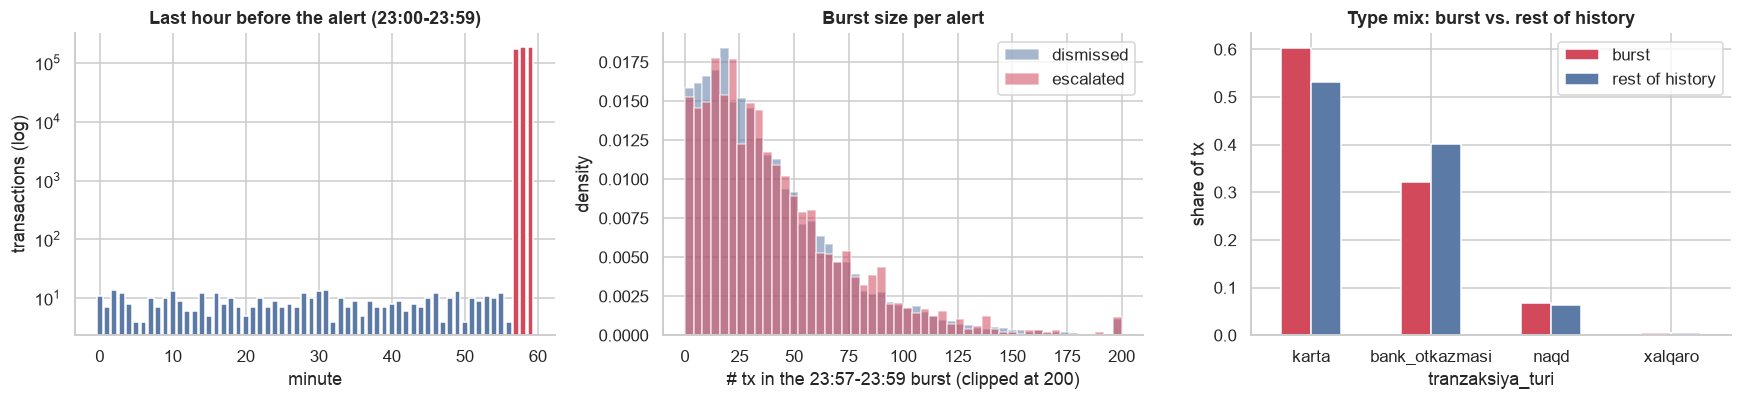

In [12]:
from src.features import trigger_burst_mask
tx["burst"] = trigger_burst_mask(tx).values
tod = tx.tranzaksiya_vaqti.dt.hour * 60 + tx.tranzaksiya_vaqti.dt.minute
last_hour = tx[(tx.days_before == 1) & (tod >= 23 * 60)]
print("tx on the day before the alert:", int((tx.days_before == 1).sum()), "| of which in 23:57-23:59:", int(((tx.days_before == 1) & (tod >= 23 * 60 + 57)).sum()))
print(f"burst rows: {tx.burst.sum():,} ({tx.burst.mean():.1%} of all); alerts with a burst: {tx[tx.burst].signal_id.nunique():,} / {len(sig):,}")
sig["burst_n"] = tx.groupby("signal_id").burst.sum()
hist_tx, burst_tx = tx[~tx.burst], tx[tx.burst]
hd = hist_tx.groupby("signal_id")
r30 = hist_tx[hist_tx.days_before <= 30].groupby("signal_id").size().reindex(sig.index).fillna(0) / 30
print(sig.groupby("y").burst_n.describe().round(1).to_string())
print(f"burst size AUC={roc_auc_score(sig.y, sig.burst_n):.4f} | corr(burst size, account's last-30-day daily rate)={np.corrcoef(sig.burst_n, r30)[0,1]:.3f}")
comp = pd.concat([burst_tx.tranzaksiya_turi.value_counts(normalize=True), hist_tx.tranzaksiya_turi.value_counts(normalize=True)], axis=1, keys=["burst", "rest of history"])
comp["burst mean amt"] = burst_tx.groupby("tranzaksiya_turi").miqdor_indeksi.mean(); comp["history mean amt"] = hist_tx.groupby("tranzaksiya_turi").miqdor_indeksi.mean()
print(comp.round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
m = last_hour.tranzaksiya_vaqti.dt.minute
ax[0].bar(np.arange(60), np.bincount(m, minlength=60), color=[C_POS if i >= 57 else C_NEG for i in range(60)])
ax[0].set(yscale="log", title="Last hour before the alert (23:00-23:59)", xlabel="minute", ylabel="transactions (log)")
for k in (0, 1):
    ax[1].hist(sig.burst_n[sig.y == k].clip(upper=200), bins=50, density=True, alpha=0.55, color=PAL[k], label=["dismissed", "escalated"][k])
ax[1].set(title="Burst size per alert", xlabel="# tx in the 23:57-23:59 burst (clipped at 200)", ylabel="density"); ax[1].legend()
comp[["burst", "rest of history"]].plot.bar(ax=ax[2], rot=0, color=[C_POS, C_NEG]); ax[2].set(title="Type mix: burst vs. rest of history", ylabel="share of tx")
save(fig, "08_trigger_burst")

**Data artifact — the trigger burst.** About **550k transactions (≈8% of all rows, ~40 per alert, present for 99% of alerts)** are stamped in the three minutes **23:57:00–23:59:59 right before the alert date**, compared with a normal rate of about 1–3 transactions per *day*. The burst leans towards cards and has much smaller amounts than the rest of the history, and its size tracks the account's recent activity rate (ρ ≈ 0.70). It is **equally present for escalated and dismissed alerts** (size AUC ≈ 0.51), so it looks like the rapid-fire activity that *triggered* the monitoring alert rather than an outcome signal.

*Leakage assessment:* all burst timestamps are before the alert, so the data is admissible under the pre-alert rule. If these were post-alert transactions clamped backwards in time, we would expect them to separate the outcomes (for example, escalated accounts being frozen), and they do not. The modeling section runs an ablation with the burst excluded entirely to put a number on this decision.

Below, recency/velocity is measured on the **burst-free** history so the burst does not mask the underlying trend.

last  3d: mean rate ratio dismissed=0.284 escalated=0.280  AUC=0.5010
last  7d: mean rate ratio dismissed=0.344 escalated=0.339  AUC=0.5010
last 30d: mean rate ratio dismissed=0.470 escalated=0.465  AUC=0.4973


last-50-tx cash share minus all-time AUC=0.5087


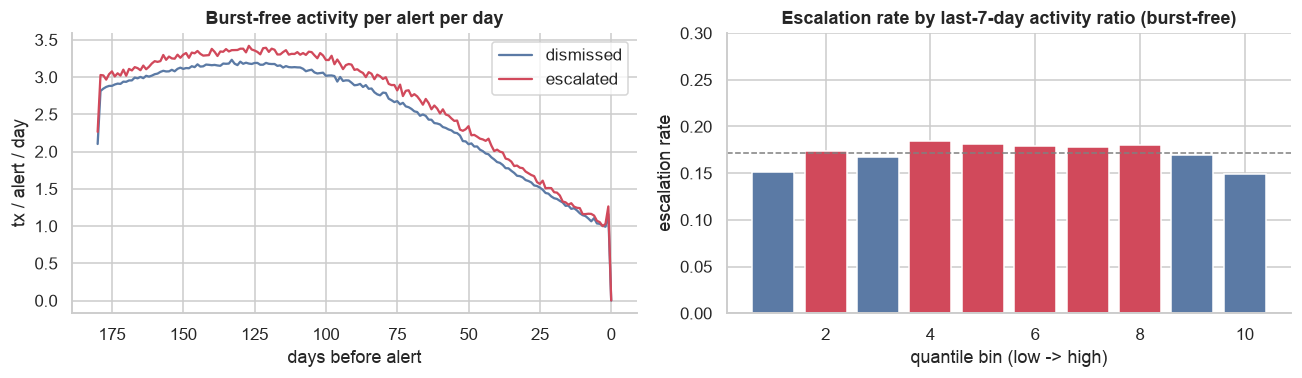

In [13]:
n_all = hist_tx.groupby("signal_id").size()
tx_all_for_recency = tx
tx = hist_tx
hist_days = tx.groupby("signal_id").days_before.max() + 1
for w in (3, 7, 30):
    nw = tx[tx.days_before <= w].groupby("signal_id").size().reindex(sig.index).fillna(0)
    sig[f"rate_ratio_{w}d"] = ((nw / (w + 1)) / (n_all / hist_days)).reindex(sig.index).fillna(0)
    print(f"last {w:2d}d: mean rate ratio dismissed={sig[f'rate_ratio_{w}d'][sig.y==0].mean():.3f} escalated={sig[f'rate_ratio_{w}d'][sig.y==1].mean():.3f}  AUC={roc_auc_score(sig.y, sig[f'rate_ratio_{w}d']):.4f}")
last50 = tx[tx.groupby("signal_id").cumcount(ascending=False) < 50]
sig["last50_cash_minus_all"] = (last50.groupby("signal_id").is_naqd.mean() - sig.share_naqd).fillna(0)
print(f"last-50-tx cash share minus all-time AUC={roc_auc_score(sig.y, sig.last50_cash_minus_all):.4f}")

daily = tx.groupby(["eskalatsiya", "days_before"]).size().unstack(0)
daily = daily / train_sig.eskalatsiya.value_counts().sort_index().values
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(daily.index, daily[0], color=C_NEG, label="dismissed"); ax[0].plot(daily.index, daily[1], color=C_POS, label="escalated")
ax[0].invert_xaxis(); ax[0].legend(); ax[0].set(title="Burst-free activity per alert per day", xlabel="days before alert", ylabel="tx / alert / day")
rate_by_quantile(ax[1], sig.rate_ratio_7d, sig.y, "Escalation rate by last-7-day activity ratio (burst-free)")
save(fig, "09_recency_velocity")
tx = tx_all_for_recency

**Recency finding (contradicts the classic AML intuition):** apart from the trigger burst, which both classes share, there is *no* behavioral acceleration before escalated alerts. Burst-free activity actually *thins out* toward the alert for both classes (from about 3 to about 1 transaction per day), and recent-versus-history ratios have AUC ≈ 0.49–0.50. We still keep the recency features (cheap and honest), but expect them to rank low.

### 2.7 Time-of-day / day-of-week

night (00-06) share AUC=0.5081


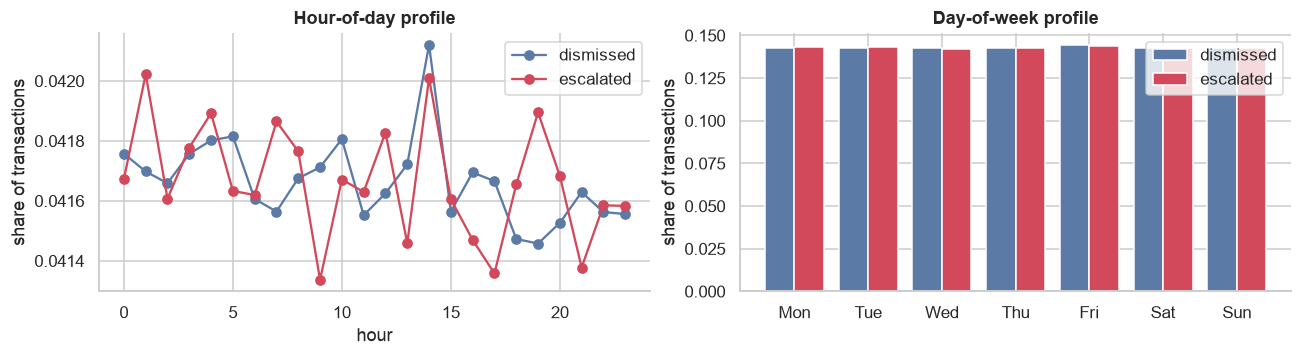

In [14]:
tt = tx[~tx.burst].copy()  # burst-free, otherwise hour 23 dominates
tt["hour"] = tt.tranzaksiya_vaqti.dt.hour; tt["dow"] = tt.tranzaksiya_vaqti.dt.dayofweek
hr = tt.groupby(["eskalatsiya", "hour"]).size().unstack(0); hr = hr / hr.sum()
dw = tt.groupby(["eskalatsiya", "dow"]).size().unstack(0); dw = dw / dw.sum()
sig["night_share"] = tt.assign(n=tt.hour < 6).groupby("signal_id").n.mean().reindex(sig.index).fillna(0)
print(f"night (00-06) share AUC={roc_auc_score(sig.y, sig.night_share):.4f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(hr.index, hr[0], marker="o", color=C_NEG, label="dismissed"); ax[0].plot(hr.index, hr[1], marker="o", color=C_POS, label="escalated")
ax[0].set(title="Hour-of-day profile", xlabel="hour", ylabel="share of transactions"); ax[0].legend()
ax[1].bar(np.arange(7) - 0.2, dw[0], 0.4, color=C_NEG, label="dismissed"); ax[1].bar(np.arange(7) + 0.2, dw[1], 0.4, color=C_POS, label="escalated")
ax[1].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]); ax[1].set(title="Day-of-week profile", ylabel="share of transactions"); ax[1].legend()
save(fig, "10_time_patterns")

On burst-free history, hour and weekday profiles of the two classes are almost identical (no night-time or weekend AML pattern). These are kept as low-cost features only.

### 2.8 EDA → feature ideas (running list)
| # | EDA finding | Feature(s) motivated |
|---|---|---|
| 1 | No future transactions; fixed ≤180-day window | Pre-signal filter kept anyway; `days_since_first`, `span_days`, `days_since_last` |
| 2 | Escalated alerts have slightly more transactions | `n_tx`, `tx_per_day`, `active_days`, per-day count stats |
| 3 | Cash share (esp. of *volume*) rises monotonically with escalation | `share_is_naqd`, `cash_share_of_volume`, `cash_intl_share`, cash amount quantiles |
| 4 | International tx slightly more common among escalated | `share_is_xalqaro`, `intl_share_of_volume`, `xalqaro_*` stats |
| 5 | Amount levels differ by type; escalated move smaller bank-transfer amounts | per type × direction mean/std/quantiles; type-adjusted `z_*` features |
| 6 | Floor-clipped inflow bank transfers ⇒ ~half the escalation rate | `cnt_is_floor`, `share_is_floor`, `amt_min` |
| 7 | Heavy right tail / type caps | `amt_max`, `amt_top5_mean`, `amt_spike_z`, `share_is_big2/3`, amount-histogram shares |
| 8 | Inflow/outflow balance weakly informative | `in_out_count_ratio`, `in_out_volume_logratio`, `net_flow_share`, pass-through (in → similar out ≤24h) |
| 9 | Burst-free activity shows no acceleration, but "sudden change" is the canonical AML hypothesis | windows 1–90 days and last-10/50 tx vs all-time (rate ratios, mix deltas, z deltas), 30-day bucket trend |
| 10 | ~40-tx trigger burst in the final 3 minutes before every alert, same size for both classes | burst tx pooled into amount/type stats (denoises them); separate burst block and burst-free timing features tested in §4.5 and rejected |
| 11 | Hour / weekday flat | `share_is_night`, `share_is_weekend`, `hour_mean/std` (low priority) |

## 3. Feature engineering
`src/features.py` turns each signal's sorted pre-alert history into **one row of ~320 features**: overall amount statistics; splits by direction, type and direction × type (counts, shares, mean/std/max/quantiles, exp-volume sums); flow ratios; type-adjusted z-score stats (train-only normalisation); activity span, gaps and per-day counts; recency windows (1/3/7/14/30/60/90 days) and last-K (10/50) tx versus all-time; 30-day activity/amount buckets and trends; spike and tail features; amount-histogram shares; pass-through counts; signal calendar features.

**Missing-value policy (identical for train and test):** counts/shares of empty subsets → 0; statistics of empty subsets (e.g. mean cash amount for an account with no cash tx) stay `NaN` because "no such activity" is itself informative and gradient boosting routes NaN natively; the linear model median-imputes and adds missing-indicator columns. Signals with very few transactions get `few_tx = 1` (n < 10), and signals with none would get `n_tx = 0` and `no_tx = 1` (none occur in this data, but the code handles it).

In [15]:
import gc
del tx, hist_tx, burst_tx, last_hour, tt, tx_all_for_recency, train_tx, test_tx, train_tx_raw, test_tx_raw; gc.collect()
t0 = time.time()
train_df, test_df, reps = build_feature_tables(use_cache=False)
FEATS = feature_columns(train_df)
X, y, X_test = train_df[FEATS], train_df[D.TARGET].to_numpy(), test_df[FEATS]
print(f"built in {time.time()-t0:.0f}s | train {train_df.shape} test {test_df.shape} | n_features={len(FEATS)}")
assert train_df.signal_id.is_unique and test_df.signal_id.is_unique
assert (train_df.signal_id.values == train_sig.signal_id.values).all() and (test_df.signal_id.values == test_sig.signal_id.values).all()
assert D.TARGET not in FEATS and "signal_id" not in FEATS
assert not np.isinf(X.to_numpy(dtype=float)).any() and not np.isinf(X_test.to_numpy(dtype=float)).any()
na = X.isna().mean().sort_values(ascending=False)
print("features with NaN (empty-subset statistics):", (na > 0).sum()); print(na.head(8).round(3).to_string())
print("few-tx signals (n<10)  train:", int(train_df.few_tx.sum()), " test:", int(test_df.few_tx.sum()), "| no-tx:", int(train_df.no_tx.sum()), int(test_df.no_tx.sum()))
print(train_df.loc[train_df.few_tx == 1, ["n_tx", "amt_mean", "amt_std", "w7_n", "share_is_naqd", D.TARGET]].head().to_string())

temporal check train: {'rows': 6987663, 'after_signal_day': 0, 'on_signal_day': 3934, 'on_signal_day_exact_midnight': 3094, 'max_days_before_signal': 180, 'rows_after_filter': 6987663}
temporal check test:  {'rows': 3027575, 'after_signal_day': 0, 'on_signal_day': 1456, 'on_signal_day_exact_midnight': 1405, 'max_days_before_signal': 180, 'rows_after_filter': 3027575}


built in 33s | train (14000, 326) test (6000, 325) | n_features=324
features with NaN (empty-subset statistics): 116
chiqim_xalqaro_mean    0.642
xalqaro_std            0.494
kirim_xalqaro_mean     0.350
xalqaro_mean           0.279
xalqaro_max            0.279
z_mean_xalqaro         0.279
chiqim_naqd_std        0.169
chiqim_naqd_mean       0.084
few-tx signals (n<10)  train: 166  test: 66 | no-tx: 0 0
     n_tx  amt_mean   amt_std  w7_n  share_is_naqd  eskalatsiya
188     9  0.283038  1.002852     2            0.0            0
306     1  0.357168       NaN     1            0.0            1
319     1  0.725483       NaN     1            0.0            0
390     6  0.278629  1.355872     2            0.0            0
483     1  0.836684       NaN     1            0.0            1


**Train/test shift check (adversarial validation):** a model that tries to tell train rows from test rows should score AUC ≈ 0.5 if the feature pipeline is consistent across splits.

In [16]:
adv_X = pd.concat([X, X_test], ignore_index=True); adv_y = np.r_[np.zeros(len(X)), np.ones(len(X_test))]
adv = M.cv_lgb(adv_X, adv_y, adv_X.iloc[:1], M.make_folds(adv_y), params=dict(n_estimators=300, learning_rate=0.05), early_stopping_rounds=None, verbose=False, name="adv")
print(f"adversarial validation AUC (train vs test): {adv.oof_auc:.4f}")

adversarial validation AUC (train vs test): 0.4959


## 4. Modeling
### 4.1 Validation design
* 5-fold **stratified** CV (`SEED = 42`), one row per `signal_id`, so an id can never appear in two folds (all transaction aggregation happens *before* splitting, inside the id).
* **No early stopping on the scoring fold.** Tree counts are fixed hyper-parameters chosen on a *different* split (`TUNE_SEED = 7`). Early stopping on the validation fold would let the fold choose its best iteration and inflate OOF AUC — noticeable when the signal is this weak.

In [17]:
folds = M.make_folds(y, seed=SEED); folds_tune = M.make_folds(y, seed=TUNE_SEED)
for i, (tr, va) in enumerate(folds):
    assert not set(train_df.signal_id.iloc[tr]) & set(train_df.signal_id.iloc[va])
    print(f"fold {i}: train={len(tr)} valid={len(va)} valid_pos_rate={y[va].mean():.4f}")
results = {}

fold 0: train=11200 valid=2800 valid_pos_rate=0.1718
fold 1: train=11200 valid=2800 valid_pos_rate=0.1718
fold 2: train=11200 valid=2800 valid_pos_rate=0.1718
fold 3: train=11200 valid=2800 valid_pos_rate=0.1718
fold 4: train=11200 valid=2800 valid_pos_rate=0.1718


### 4.2 Baseline — logistic regression on a few obvious features

In [18]:
BASE = ["n_tx", "amt_mean", "share_is_naqd", "share_is_xalqaro", "share_is_in", "tx_per_day", "amt_max"]
results["logreg_7feat"] = M.cv_logreg(train_df[BASE], y, test_df[BASE], folds, C=1.0)

  [logreg] fold 0: AUC=0.5712
  [logreg] fold 1: AUC=0.5516
  [logreg] fold 2: AUC=0.5598
  [logreg] fold 3: AUC=0.5742
  [logreg] fold 4: AUC=0.5586
  [logreg] OOF AUC=0.5629  folds mean=0.5631 +/- 0.0084


### 4.3 Hyper-parameters (light tuning on the separate split)
LightGBM parameters come from `src/tune.py` (30 Optuna TPE trials, scored on `TUNE_SEED` folds, saved to `models/lgb_best_params.json`). The search landscape was flat (0.634–0.642 across trials), i.e. tuning matters little here. The logistic-regression `C` is picked from a small grid on the same tuning split.

In [19]:
PARAMS_PATH = MODELS / "lgb_best_params.json"
if not PARAMS_PATH.exists():
    from src.tune import run as run_tuning
    run_tuning()
LGB_BEST = json.loads(PARAMS_PATH.read_text()); print("LightGBM params:", LGB_BEST)

c_scores = {C: M.cv_logreg(X, y, X.iloc[:1], folds_tune, C=C, verbose=False).oof_auc for C in (0.0003, 0.001, 0.003, 0.01, 0.03)}
C_BEST = max(c_scores, key=c_scores.get); print("logreg C on tuning split:", {k: round(v, 4) for k, v in c_scores.items()}, "-> C =", C_BEST)

LightGBM params: {'learning_rate': 0.01, 'n_estimators': 300, 'num_leaves': 25, 'min_child_samples': 82, 'colsample_bytree': 0.46173258891547064, 'subsample': 0.9400952803984711, 'reg_lambda': 2.840430724488196, 'reg_alpha': 0.1010373285001628, 'min_split_gain': 0.03602556667988077}


logreg C on tuning split: {0.0003: 0.6412, 0.001: 0.6439, 0.003: 0.6421, 0.01: 0.6384, 0.03: 0.6349} -> C = 0.001


### 4.4 Models on the evaluation folds

In [20]:
results["logreg_all"] = M.cv_logreg(X, y, X_test, folds, C=C_BEST)

lgb_runs = [M.cv_lgb(X, y, X_test, folds, params=LGB_BEST, seed=s, early_stopping_rounds=None, name=f"lgb_s{s}") for s in LGB_SEEDS]
lgb_oof = np.mean([r.oof for r in lgb_runs], axis=0); lgb_test = np.mean([r.test for r in lgb_runs], axis=0)
results["lgb"] = M.CVResult("lgb", lgb_oof, lgb_test, [roc_auc_score(y[va], lgb_oof[va]) for _, va in folds],
                            pd.concat([r.importance for r in lgb_runs], axis=1).mean(axis=1).sort_values(ascending=False))
results["lgb"]._y = y
print(f"LightGBM 3-seed bag OOF AUC = {results['lgb'].oof_auc:.4f}")

  [logreg] fold 0: AUC=0.6598


  [logreg] fold 1: AUC=0.6206


  [logreg] fold 2: AUC=0.6324


  [logreg] fold 3: AUC=0.6515


  [logreg] fold 4: AUC=0.6387
  [logreg] OOF AUC=0.6405  folds mean=0.6406 +/- 0.0139


...

  [lgb_s44] fold 0: AUC=0.6598


  [lgb_s44] fold 1: AUC=0.6240


  [lgb_s44] fold 2: AUC=0.6386


  [lgb_s44] fold 3: AUC=0.6350


  [lgb_s44] fold 4: AUC=0.6356
  [lgb_s44] OOF AUC=0.6382  folds mean=0.6386 +/- 0.0117
LightGBM 3-seed bag OOF AUC = 0.6392


In [21]:
XGB_P = dict(learning_rate=0.01, n_estimators=600, max_depth=3, min_child_weight=10, colsample_bytree=0.3, subsample=0.8, reg_lambda=5.0)
results["xgb"] = M.cv_xgb(X, y, X_test, folds, params=XGB_P, early_stopping=False)
CAT_P = dict(learning_rate=0.03, iterations=400, depth=5, l2_leaf_reg=5.0)
results["cat"] = M.cv_cat(X, y, X_test, folds, params=CAT_P, early_stopping=False)

  [xgb] fold 0: AUC=0.6587


  [xgb] fold 1: AUC=0.6279


  [xgb] fold 2: AUC=0.6381


  [xgb] fold 3: AUC=0.6320


  [xgb] fold 4: AUC=0.6297
  [xgb] OOF AUC=0.6370  folds mean=0.6373 +/- 0.0113


  [cat] fold 0: AUC=0.6463


  [cat] fold 1: AUC=0.6235


  [cat] fold 2: AUC=0.6273


  [cat] fold 3: AUC=0.6279


  [cat] fold 4: AUC=0.6199
  [cat] OOF AUC=0.6287  folds mean=0.6290 +/- 0.0091


### 4.5 Leak sanity checks
1. **Permuted-target test** — the same pipeline trained on shuffled labels must give AUC ≈ 0.5.
2. **Feature importance** — no single feature should dominate (a classic leak signature).

permuted-label OOF AUC: 0.4947  (should be ~0.5)
top feature holds 4.2% of total gain; top-10 hold 21.6%
amt_min                       0.0421
kirim_naqd_q90                0.0279
chiqim_bank_otkazmasi_q50     0.0228
chiqim_bank_otkazmasi_q90     0.0215
cash_share_of_volume          0.0213
kirim_naqd_mean               0.0192
chiqim_bank_otkazmasi_mean    0.0185
share_is_floor                0.0183
chiqim_karta_std              0.0132
karta_max                     0.0113
chiqim_karta_q90              0.0108
chiqim_bank_otkazmasi_std     0.0106
hist_bank_b10                 0.0093
kirim_naqd_q50                0.0089
z_mean_bank_otkazmasi         0.0089
chiqim_karta_q50              0.0086
hist_bank_b6                  0.0085
bank_otkazmasi_std            0.0084
amt_skew                      0.0083
hist_karta_b8                 0.0080


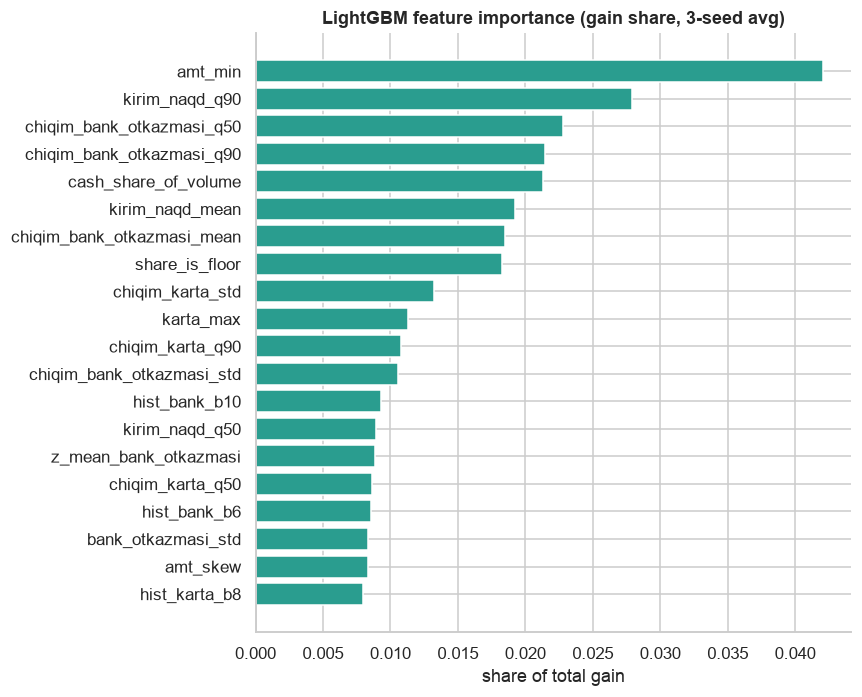

In [22]:
y_perm = np.random.RandomState(SEED).permutation(y)
perm = M.cv_lgb(X, y_perm, X.iloc[:1], M.make_folds(y_perm), params=LGB_BEST, early_stopping_rounds=None, verbose=False)
print(f"permuted-label OOF AUC: {perm.oof_auc:.4f}  (should be ~0.5)")

imp = results["lgb"].importance; imp_share = imp / imp.sum()
print(f"top feature holds {imp_share.iloc[0]:.1%} of total gain; top-10 hold {imp_share.head(10).sum():.1%}")
print(imp_share.head(20).round(4).to_string())
top = imp_share.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top.index, top.values, color=C_ACC); ax.set(title="LightGBM feature importance (gain share, 3-seed avg)", xlabel="share of total gain")
save(fig, "11_feature_importance")

**Importance sanity check.** The top features are exactly the EDA signals — the account's lowest amount (`amt_min`, which captures floor-clipped inflows), outgoing bank-transfer amount level, cash share of volume, cash-deposit amount quantiles, card amount spread. No feature holds an implausible share of the gain, and the permuted-label run collapses to ≈ 0.5, so there is no sign of target or temporal leakage.

### 4.5b Feature-set ablation — how to treat the trigger burst (§2.6)
The same LightGBM + logistic pair (equal-weight blend) is run on four feature-set variants, on both the tuning split and the evaluation folds. Selection uses the tuning split.

In [23]:
import gc
from src.features import trigger_burst_mask
abl_sig, abl_tx, _ = D.load_split("train")
abl_stats = fit_type_stats(abl_tx)
variants = {
    "pooled history (final)": train_df,
    "+ separate burst block": build_features(abl_tx, abl_sig, abl_stats, burst_block=True),
    "+ burst-free timing block": build_features(abl_tx, abl_sig, abl_stats, hist_timing=True),
    "burst excluded entirely": build_features(abl_tx.loc[~trigger_burst_mask(abl_tx)].reset_index(drop=True), abl_sig, abl_stats),
}
rows = {}
for name, df in variants.items():
    assert (df.signal_id.values == train_df.signal_id.values).all()
    Xv = df[feature_columns(df)]
    row = {"n_features": Xv.shape[1]}
    for split_name, fl in (("tuning split", folds_tune), ("eval folds", folds)):
        l = M.cv_lgb(Xv, y, Xv.iloc[:1], fl, params=LGB_BEST, early_stopping_rounds=None, verbose=False)
        r = M.cv_logreg(Xv, y, Xv.iloc[:1], fl, C=C_BEST, verbose=False)
        b, _ = M.blend_pairs([(l.oof, l.oof), (r.oof, r.oof)], [0.5, 0.5])
        row.update({f"lgb ({split_name})": l.oof_auc, f"logreg ({split_name})": r.oof_auc, f"blend ({split_name})": roc_auc_score(y, b)})
    rows[name] = row
ablation = pd.DataFrame(rows).T
print(ablation.round(4).to_string())
del abl_tx, variants; gc.collect()

                           n_features  lgb (tuning split)  logreg (tuning split)  blend (tuning split)  lgb (eval folds)  logreg (eval folds)  blend (eval folds)
pooled history (final)          324.0              0.6419                 0.6439                0.6471            0.6382               0.6405              0.6435
+ separate burst block          350.0              0.6394                 0.6423                0.6449            0.6366               0.6398              0.6425
+ burst-free timing block       424.0              0.6399                 0.6393                0.6445            0.6350               0.6365              0.6405
burst excluded entirely         324.0              0.6392                 0.6365                0.6425            0.6358               0.6340              0.6397


9

Pooling the burst with the rest of the history is best: the burst transactions carry the same account-level amount/type signal, so including them gives the amount statistics more samples. Adding separate burst or burst-free timing blocks only adds noise columns. Dropping the burst entirely costs only ~0.004–0.005 AUC, so the model does **not** hinge on it — a useful robustness check if the burst turned out to be clamped post-alert data.

### 4.6 Model comparison and blend
The logistic model on all features is nearly as good as boosting but only ~0.79 correlated with it, so we blend in **standardised logit space**. The blend weight is chosen on the *tuning* split (`TUNE_SEED`), then evaluated on the evaluation folds.

In [24]:
lgb_t = M.cv_lgb(X, y, X.iloc[:1], folds_tune, params=LGB_BEST, early_stopping_rounds=None, verbose=False)
lr_t = M.cv_logreg(X, y, X.iloc[:1], folds_tune, C=C_BEST, verbose=False)
w_scores = {}
for w in np.round(np.arange(0, 0.75, 0.05), 2):
    s, _ = M.blend_pairs([(lgb_t.oof, lgb_t.oof), (lr_t.oof, lr_t.oof)], [1 - w, w]); w_scores[w] = roc_auc_score(y, s)
W_LR = max(w_scores, key=w_scores.get)
print("tuning-split blend AUC by logreg weight:", {k: round(v, 4) for k, v in w_scores.items()}); print("chosen logreg weight:", W_LR)

blend_oof, blend_test_cv = M.blend_pairs([(results["lgb"].oof, results["lgb"].test), (results["logreg_all"].oof, results["logreg_all"].test)], [1 - W_LR, W_LR])
print(f"\nFINAL blend OOF AUC (evaluation folds) = {roc_auc_score(y, blend_oof):.4f}")
print("per-fold:", [round(roc_auc_score(y[va], blend_oof[va]), 4) for _, va in folds])

s3, _ = M.blend_pairs([(results[k].oof, results[k].test) for k in ("lgb", "xgb", "logreg_all")], [(1 - W_LR) / 2, (1 - W_LR) / 2, W_LR])
print(f"(alternative) lgb+xgb+logreg blend OOF AUC = {roc_auc_score(y, s3):.4f}")
print("OOF correlation:\n", pd.DataFrame({k: results[k].oof for k in ("lgb", "xgb", "cat", "logreg_all")}).corr().round(3).to_string())

tuning-split blend AUC by logreg weight: {np.float64(0.0): 0.6419, np.float64(0.05): 0.6427, np.float64(0.1): 0.6434, np.float64(0.15): 0.644, np.float64(0.2): 0.6446, np.float64(0.25): 0.6452, np.float64(0.3): 0.6457, np.float64(0.35): 0.6462, np.float64(0.4): 0.6465, np.float64(0.45): 0.6469, np.float64(0.5): 0.6471, np.float64(0.55): 0.6473, np.float64(0.6): 0.6474, np.float64(0.65): 0.6474, np.float64(0.7): 0.6473}
chosen logreg weight: 0.65

FINAL blend OOF AUC (evaluation folds) = 0.6440
per-fold: [0.6654, 0.6269, 0.638, 0.6504, 0.6401]
(alternative) lgb+xgb+logreg blend OOF AUC = 0.6436
OOF correlation:
              lgb    xgb    cat  logreg_all
lgb         1.00  0.970  0.930       0.810
xgb         0.97  1.000  0.948       0.837
cat         0.93  0.948  1.000       0.830
logreg_all  0.81  0.837  0.830       1.000


                  OOF AUC  fold mean  fold std
logreg_7feat       0.5629     0.5631    0.0084
cat                0.6287     0.6290    0.0091
xgb                0.6370     0.6373    0.0113
lgb                0.6392     0.6395    0.0108
logreg_all         0.6405     0.6406    0.0139
blend lgb+logreg   0.6440     0.6441    0.0130


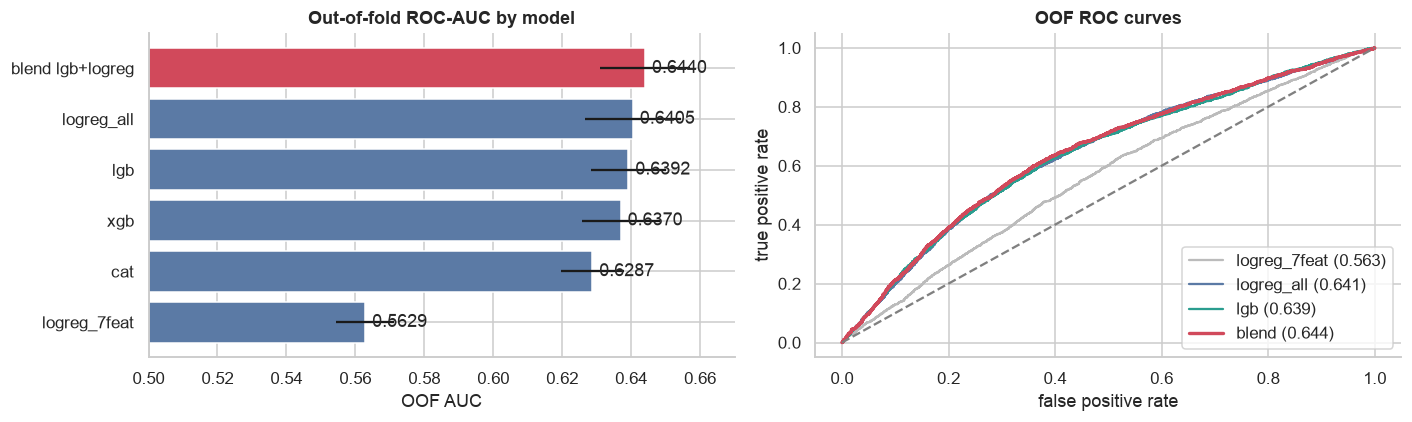

In [25]:
summary = pd.DataFrame({k: {"OOF AUC": r.oof_auc, "fold mean": np.mean(r.fold_auc), "fold std": np.std(r.fold_auc)} for k, r in results.items()}).T
summary.loc["blend lgb+logreg"] = [roc_auc_score(y, blend_oof), np.mean([roc_auc_score(y[va], blend_oof[va]) for _, va in folds]), np.std([roc_auc_score(y[va], blend_oof[va]) for _, va in folds])]
summary = summary.sort_values("OOF AUC"); print(summary.round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(summary.index, summary["OOF AUC"], xerr=summary["fold std"], color=[C_POS if "blend" in i else C_NEG for i in summary.index])
ax[0].set(xlim=(0.5, 0.67), title="Out-of-fold ROC-AUC by model", xlabel="OOF AUC")
for i, v in enumerate(summary["OOF AUC"]): ax[0].text(v + 0.002, i, f"{v:.4f}", va="center")
for k, c in [("logreg_7feat", "#bbbbbb"), ("logreg_all", C_NEG), ("lgb", C_ACC)]:
    fpr, tpr, _ = roc_curve(y, results[k].oof); ax[1].plot(fpr, tpr, color=c, label=f"{k} ({results[k].oof_auc:.3f})")
fpr, tpr, _ = roc_curve(y, blend_oof); ax[1].plot(fpr, tpr, color=C_POS, lw=2.2, label=f"blend ({roc_auc_score(y, blend_oof):.3f})")
ax[1].plot([0, 1], [0, 1], ls="--", color="grey"); ax[1].set(title="OOF ROC curves", xlabel="false positive rate", ylabel="true positive rate"); ax[1].legend(loc="lower right")
save(fig, "12_model_comparison")

## 5. Final fit, calibration and submission
* Refit on **all** 14,000 training signals with the same pipeline: LightGBM (3 seeds, fixed trees ×1.1 for the 25% larger training set) and logistic regression.
* Blend in standardised logit space using the OOF mean/std of each model, then **Platt-scale** the blended score to probabilities with a calibrator fit on the OOF blend (monotone ⇒ AUC-preserving).

corr(full-fit, fold-avg) test preds  lgb: 0.9934  logreg: 0.9994
calibrated OOF AUC 0.6440 (unchanged) | mean OOF prob 0.1718 vs base rate 0.1718
test probability distribution:
count    6000.0000
mean        0.1735
std         0.0713
min         0.0071
1%          0.0543
10%         0.0920
50%         0.1596
90%         0.2763
99%         0.3573
max         0.4945


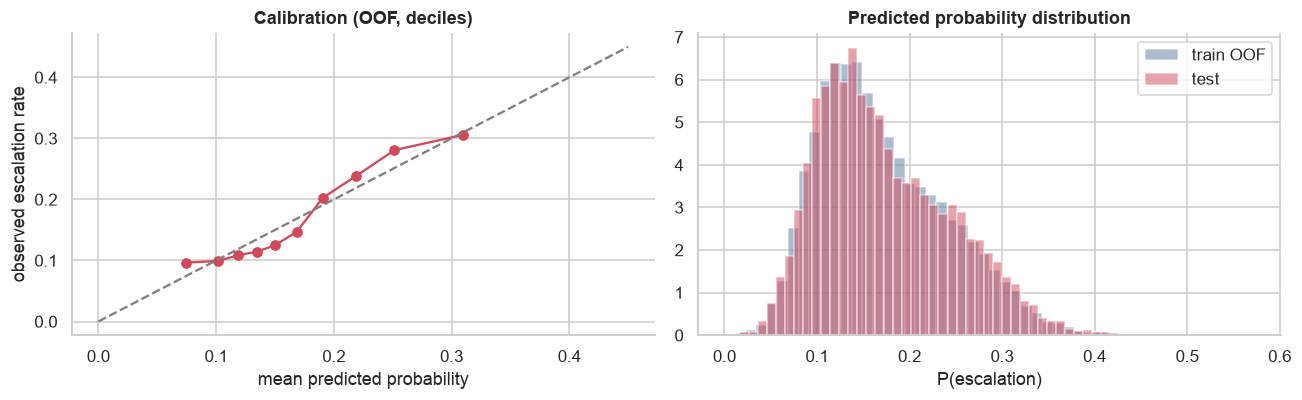

In [26]:
full_params = {**LGB_BEST, "n_estimators": int(round(LGB_BEST["n_estimators"] * 1.1))}
lgb_models = M.fit_lgb_full(X, y, full_params, seeds=LGB_SEEDS)
lgb_test_full = np.mean([m.predict_proba(X_test)[:, 1] for m in lgb_models], axis=0)
lr_model = M.make_logreg(C_BEST).fit(X, y)
lr_test_full = lr_model.predict_proba(X_test)[:, 1]
print("corr(full-fit, fold-avg) test preds  lgb:", round(np.corrcoef(lgb_test_full, results["lgb"].test)[0, 1], 4),
      " logreg:", round(np.corrcoef(lr_test_full, results["logreg_all"].test)[0, 1], 4))

_, blend_test = M.blend_pairs([(results["lgb"].oof, lgb_test_full), (results["logreg_all"].oof, lr_test_full)], [1 - W_LR, W_LR])
calibrate = M.fit_platt(blend_oof, y)
p_oof, p_test = calibrate(blend_oof), calibrate(blend_test)
print(f"calibrated OOF AUC {roc_auc_score(y, p_oof):.4f} (unchanged) | mean OOF prob {p_oof.mean():.4f} vs base rate {y.mean():.4f}")
print("test probability distribution:"); print(pd.Series(p_test).describe(percentiles=[.01, .1, .5, .9, .99]).round(4).to_string())

bins = pd.qcut(p_oof, 10, labels=False)
rel = pd.DataFrame({"pred": p_oof, "obs": y}).groupby(bins).mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(rel.pred, rel.obs, marker="o", color=C_POS); ax[0].plot([0, .45], [0, .45], ls="--", color="grey")
ax[0].set(title="Calibration (OOF, deciles)", xlabel="mean predicted probability", ylabel="observed escalation rate")
ax[1].hist(p_oof, bins=50, density=True, alpha=0.5, color=C_NEG, label="train OOF"); ax[1].hist(p_test, bins=50, density=True, alpha=0.5, color=C_POS, label="test")
ax[1].set(title="Predicted probability distribution", xlabel="P(escalation)"); ax[1].legend()
save(fig, "13_calibration")

In [27]:
import joblib
for i, m in enumerate(lgb_models): m.booster_.save_model(str(MODELS / f"lgb_full_seed{LGB_SEEDS[i]}.txt"))
joblib.dump({"logreg": lr_model, "features": FEATS, "lgb_params": full_params, "logreg_C": C_BEST, "w_logreg": W_LR,
             "oof_stats": {"lgb": (M.logit(results["lgb"].oof).mean(), M.logit(results["lgb"].oof).std()),
                           "logreg": (M.logit(results["logreg_all"].oof).mean(), M.logit(results["logreg_all"].oof).std())}},
            MODELS / "final_ensemble.joblib")
pd.DataFrame({"signal_id": train_df.signal_id, "y": y, "oof_lgb": results["lgb"].oof, "oof_logreg": results["logreg_all"].oof,
              "oof_blend_prob": p_oof}).to_csv(MODELS / "oof_predictions.csv", index=False)
print(sorted(p.name for p in MODELS.iterdir()))

['feature_cache', 'final_ensemble.joblib', 'lgb_best_params.json', 'lgb_full_seed42.txt', 'lgb_full_seed43.txt', 'lgb_full_seed44.txt', 'oof_predictions.csv']


In [28]:
sub = pd.DataFrame({"signal_id": test_df.signal_id.values, "ehtimollik": p_test})
sub = sample_sub[["signal_id"]].merge(sub, on="signal_id", how="left")

checks = {
    "columns are exactly [signal_id, ehtimollik]": list(sub.columns) == ["signal_id", "ehtimollik"],
    "row count equals sample_submission": len(sub) == len(sample_sub),
    "no duplicate signal_id": not sub.signal_id.duplicated().any(),
    "same id set as sample_submission": set(sub.signal_id) == set(sample_sub.signal_id),
    "same id set as test_signals": set(sub.signal_id) == set(test_sig.signal_id),
    "same id order as sample_submission": (sub.signal_id.values == sample_sub.signal_id.values).all(),
    "no missing values": not sub.isna().any().any(),
    "all probabilities in [0, 1]": bool(sub.ehtimollik.between(0, 1).all()),
    "predictions not degenerate (std > 0.01)": sub.ehtimollik.std() > 0.01,
}
print("SUBMISSION VALIDATION REPORT"); print("-" * 50)
for k, v in checks.items(): print(f"[{'PASS' if v else 'FAIL'}] {k}")
assert all(checks.values()), "submission validation failed"
path = OUTPUT / "team_365B6DEC.csv"
sub.to_csv(path, index=False)
back = pd.read_csv(path)
assert list(back.columns) == ["signal_id", "ehtimollik"] and len(back) == len(sample_sub)
print("-" * 50); print(f"written {path.relative_to(ROOT)}  rows={len(back)}  mean prob={back.ehtimollik.mean():.4f}")
print(back.head().to_string(index=False))

SUBMISSION VALIDATION REPORT
--------------------------------------------------
[PASS] columns are exactly [signal_id, ehtimollik]
[PASS] row count equals sample_submission
[PASS] no duplicate signal_id
[PASS] same id set as sample_submission
[PASS] same id set as test_signals
[PASS] same id order as sample_submission
[PASS] no missing values
[PASS] all probabilities in [0, 1]
[PASS] predictions not degenerate (std > 0.01)
--------------------------------------------------
written output/team_365B6DEC.csv  rows=6000  mean prob=0.1735
signal_id  ehtimollik
SG_000001    0.135380
SG_000007    0.183924
SG_000009    0.102225
SG_000010    0.148467
SG_000011    0.142138


## 6. Summary
* **Leakage:** no transaction is dated after its alert (both splits); the pre-alert filter is kept defensively. Permuted-label AUC ≈ 0.5, adversarial validation ≈ 0.5, and no feature dominates importance.
* **Data artifact:** ~8% of transactions are a trigger burst packed into 23:57–23:59 before every alert. It is the same size for both classes; the model is robust to dropping it (§4.5b).
* **Signal is weak and diffuse** — the best single features reach AUC ≈ 0.57. What separates escalated alerts is the *composition* of an account's flows (more cash volume, smaller bank-transfer and card amounts once type is controlled for, no floor-clipped inflows) rather than bursts, timing or night activity.
* **Model:** LightGBM (3-seed bag, Optuna-tuned on a separate split, fixed tree count) blended in logit space with an L2 logistic regression on the same 324 features, then Platt-calibrated. The final out-of-fold AUC is printed in §4.6.